# DATA MODELING & ANALYSIS

In [11]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)


In [2]:
# Load data

df = pd.read_csv('cleaned_data.csv')

In [3]:
#Converts order date column into datetime format.

df['order_date'] = pd.to_datetime(df['order_date'])
df['signup_date'] = pd.to_datetime(df['signup_date'])

In [15]:
# RFM Analysis:-

In [4]:
#snapshot date
snapshot_date = (
    df['order_date'].max() +
    pd.Timedelta(days=1)
)
# Create RFM table

rfm = df.groupby('customer_id').agg({

    'order_date':
    lambda x: (
        snapshot_date - x.max()
    ).days,

    'order_id': 'nunique',

    'revenue': 'sum'

})

# Rename column

rfm.columns = [
    'Recency',
    'Frequency',
    'Monetary'
]

#Create RFM scores

rfm['R_score'] = pd.qcut(
    rfm['Recency'],
    5,
    labels=[5,4,3,2,1]
)

rfm['F_score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

rfm['M_score'] = pd.qcut(
    rfm['Monetary'],
    5,
    labels=[1,2,3,4,5]
)

# Final RFM score

rfm['RFM_Score'] = (

    rfm['R_score'].astype(str)

    +

    rfm['F_score'].astype(str)

    +

    rfm['M_score'].astype(str)
)

rfm['R_score'] = rfm['R_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['M_score'] = rfm['M_score'].astype(int)

# Customer Segmentation

def segment(row):

    if row['RFM_Score'] == '555':
        return 'Champion'

    elif row['F_score'] >= 4:
        return 'Loyal'

    else:
        return 'Regular'

rfm['Segment'] = rfm.apply(
    segment,
    axis=1
)


rfm.head(10)


,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
customer_id,,,,,,,,
1,9,8,2632.0,5,5,5,555,Champion
2,102,3,2075.0,2,3,4,234,Regular
3,40,1,180.0,4,1,1,411,Regular
4,81,4,774.0,3,4,2,342,Loyal
5,36,7,3014.0,4,5,5,455,Loyal
6,192,3,1597.0,1,3,4,134,Regular
7,95,2,1087.0,3,2,3,323,Regular
8,161,2,581.0,2,2,2,222,Regular
9,73,3,961.0,3,3,3,333,Regular


In [ ]:
# Churn Prediction

In [5]:
# Create table variable

rfm['Churn'] = np.where(
    rfm['Recency'] > 90,
    1,
    0
)

# Features & Target

X = rfm[[
    'Recency',
    'Frequency',
    'Monetary'
]]

y = rfm['Churn']


In [6]:
rfm['Churn'].value_counts()

Churn
0    162
1    115
Name: count, dtype: int64

##### *162 Active Customer
##### *115 Chrun Customer

In [7]:
rfm

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment,Churn
customer_id,,,,,,,,,
1,9,8,2632.0,5,5,5,555,Champion,0
2,102,3,2075.0,2,3,4,234,Regular,1
3,40,1,180.0,4,1,1,411,Regular,0
4,81,4,774.0,3,4,2,342,Loyal,0
5,36,7,3014.0,4,5,5,455,Loyal,0
...,...,...,...,...,...,...,...,...,...
296,219,4,2410.0,1,4,5,145,Loyal,1
297,222,1,789.0,1,1,2,112,Regular,1
298,55,1,330.0,4,1,1,411,Regular,0


In [8]:
# Train Test Split

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )
)


Logistic Regression Accuracy:

Accuracy Score:
1.0

Precision Score:
1.0

Recall Score:
1.0

F1 Score:
1.0

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        34
           1       1.00      1.00      1.00        22

    accuracy                           1.00        56
   macro avg       1.00      1.00      1.00        56
weighted avg       1.00      1.00      1.00        56



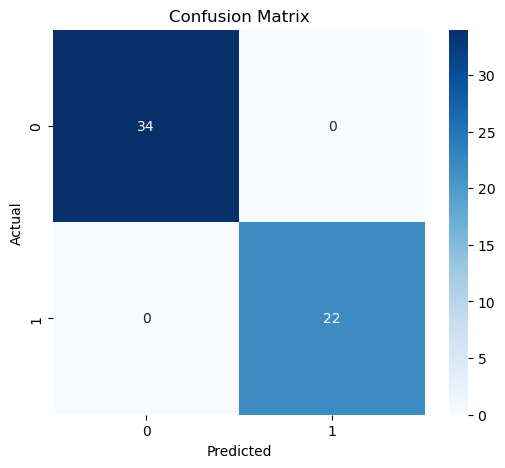


ROC AUC Score:
1.0


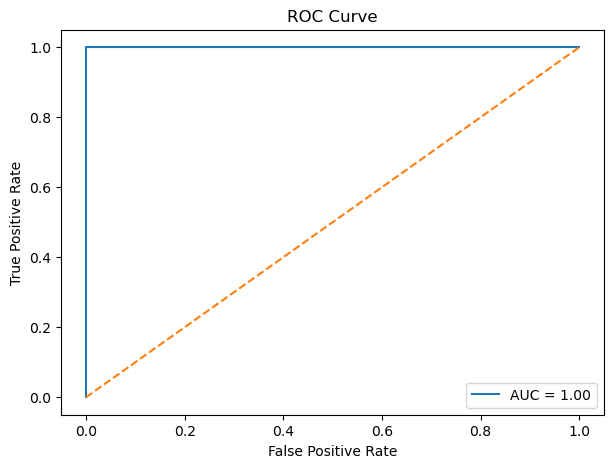


Feature Importance:

     Feature  Coefficient
0    Recency     1.037963
2   Monetary    -0.000454
1  Frequency    -0.232625

Intercept:
[-91.75436605]

Training Score:
1.0

Testing Score:
1.0

Model is balanced.


In [12]:
# Logistic Regression

lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("\nLogistic Regression Accuracy:")

# ACCURACY

accuracy = accuracy_score(y_test, lr_pred)

print("\nAccuracy Score:")
print(accuracy)


# PRECISION


precision = precision_score(y_test, lr_pred)

print("\nPrecision Score:")
print(precision)


# RECALL


recall = recall_score(y_test, lr_pred)

print("\nRecall Score:")
print(recall)


# F1 SCORE

f1 = f1_score(y_test, lr_pred)

print("\nF1 Score:")
print(f1)


# CLASSIFICATION REPORT

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        lr_pred
    )
)

# CONFUSION MATRIX

cm = confusion_matrix(
    y_test,
    lr_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ROC AUC SCORE

lr_prob = lr_model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(
    y_test,
    lr_prob
)

print("\nROC AUC Score:")
print(roc_auc)

# ROC CURVE

fpr, tpr, thresholds = roc_curve(
    y_test,
    lr_prob
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.2f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

# FEATURE IMPORTANCE

importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
})

importance = importance.sort_values(
    by='Coefficient',
    ascending=False
)

print("\nFeature Importance:\n")

print(importance)

# INTERCEPT

print("\nIntercept:")
print(lr_model.intercept_)

# TRAIN & TEST SCORE

train_score = lr_model.score(
    X_train,
    y_train
)

test_score = lr_model.score(
    X_test,
    y_test
)

print("\nTraining Score:")
print(train_score)

print("\nTesting Score:")
print(test_score)

# OVERFITTING CHECK

if train_score - test_score > 0.10:
    print("\nModel may be overfitting.")
else:
    print("\nModel is balanced.")

##### A Logistic Regression model achieving 100% accuracy (1.0)

In [57]:
#Export file
rfm.to_csv(
    "rfm_analysis.csv"
)